In [12]:
import sys
sys.path.append('../src')

from preprocessing import cut_isEMTight, cut_pt, cut_eta
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
file = uproot.open('../data/raw/qcd/DAOD_PHYSLITE.38191666._000036.pool.root.1')

tree = file['CollectionTree']

In [14]:
pt = tree["AnalysisPhotonsAuxDyn.pt"].array()
eta = tree["AnalysisPhotonsAuxDyn.eta"].array()
phi = tree["AnalysisPhotonsAuxDyn.phi"].array()

ptcone20 = tree["AnalysisPhotonsAuxDyn.ptcone20_CloseByCorr"].array()
topoetcone20 = tree["AnalysisPhotonsAuxDyn.topoetcone20_CloseByCorr"].array()
topoetcone40 = tree["AnalysisPhotonsAuxDyn.topoetcone40_CloseByCorr"].array()

f1 = tree["AnalysisPhotonsAuxDyn.f1"].array()


isEMTight = tree["AnalysisPhotonsAuxDyn.DFCommonPhotonsIsEMTight"].array()

truthOrigin = tree["AnalysisPhotonsAuxDyn.truthOrigin"].array()

print(f"Number of events before cuts: {len(pt)}")

Number of events before cuts: 200000


In [15]:
# ===== ARRAY SYNCHRONIZATION (DATA QUALITY) =====
# In rare cases (~0.0005%), photon isolation variables (ptcone20, topoetcone) 
# may not be reconstructed for all photons in an event (e.g., photons in 
# calorimeter boundary regions or reconstruction failures).
# 
# This creates array length mismatches between kinematic (pt, eta, phi) and 
# isolation variables, causing indexing errors during boolean masking.
# 
# Removed such events by requiring all photon-level arrays to have 
# consistent multiplicities per event. 

pt_len = ak.num(pt)
ptcone20_len = ak.num(ptcone20)
topetcone20_len = ak.num(topoetcone20)
topetcone40_len = ak.num(topoetcone40)
f1_len = ak.num(f1)

sync_mask = (
    (pt_len == ptcone20_len) &
    (pt_len == topetcone20_len) &
    (pt_len == topetcone40_len) &
    (pt_len == f1_len)
)

n_removed = len(pt) - np.sum(sync_mask)
print(f"removing {n_removed} events with array length mismatch")

#Synchronize all arrays
pt = pt[sync_mask]
eta = eta[sync_mask]
phi = phi[sync_mask]
ptcone20 = ptcone20[sync_mask]
topoetcone20 = topoetcone20[sync_mask]
topoetcone40 = topoetcone40[sync_mask]
f1 = f1[sync_mask]
isEMTight = isEMTight[sync_mask]
truthOrigin = truthOrigin[sync_mask]

print(f"Number of events after synchronization: {len(pt)}")

removing 1 events with array length mismatch
Number of events after synchronization: 199999


In [16]:
# isEMTight cut

tight_mask = cut_isEMTight(isEMTight)

pt = pt[tight_mask]
eta = eta[tight_mask]
phi = phi[tight_mask]
ptcone20 = ptcone20[tight_mask]
topoetcone20 = topoetcone20[tight_mask]
topoetcone40 = topoetcone40[tight_mask]
f1 = f1[tight_mask]
truthOrigin = truthOrigin[tight_mask]

In [17]:
# at least 2 tight photons

n_photons = ak.num(pt)
has_2plus = (n_photons >= 2)

pt = pt[has_2plus]
eta = eta[has_2plus]
phi = phi[has_2plus]
ptcone20 = ptcone20[has_2plus]
topoetcone20 = topoetcone20[has_2plus]
topoetcone40 = topoetcone40[has_2plus]
f1 = f1[has_2plus]
truthOrigin = truthOrigin[has_2plus]


print(f"Number of events after requiring at least 2 tight photons: {len(pt)}")

Number of events after requiring at least 2 tight photons: 120478


In [18]:
# lead/sublead pt cuts
sorted_indices = ak.argsort(pt, axis=1, ascending=False)

pt_sorted = pt[sorted_indices]
eta_sorted = eta[sorted_indices]
phi_sorted = phi[sorted_indices]
ptcone20_sorted = ptcone20[sorted_indices]
topoetcone20_sorted = topoetcone20[sorted_indices]
topoetcone40_sorted = topoetcone40[sorted_indices]
f1_sorted = f1[sorted_indices]
truthOrigin_sorted = truthOrigin[sorted_indices]

#Lead photons
pt_lead = pt_sorted[:, 0]
eta_lead = eta_sorted[:, 0]
phi_lead = phi_sorted[:, 0]
ptcone20_lead = ptcone20_sorted[:, 0]
topoetcone20_lead = topoetcone20_sorted[:, 0]
topoetcone40_lead = topoetcone40_sorted[:, 0]
f1_lead = f1_sorted[:, 0]
truthOrigin_lead = truthOrigin_sorted[:, 0]

#Sublead photons
pt_sublead = pt_sorted[:, 1]
eta_sublead = eta_sorted[:, 1]
phi_sublead = phi_sorted[:, 1]
ptcone20_sublead = ptcone20_sorted[:, 1]
topoetcone20_sublead = topoetcone20_sorted[:, 1]
topoetcone40_sublead = topoetcone40_sorted[:, 1]
f1_sublead = f1_sorted[:, 1]
truthOrigin_sublead = truthOrigin_sorted[:, 1]

In [19]:
# pt cut

pt_cut = cut_pt(pt_lead, pt_sublead)

pt_lead = pt_lead[pt_cut]
pt_sublead = pt_sublead[pt_cut]
eta_lead = eta_lead[pt_cut]
eta_sublead = eta_sublead[pt_cut]
phi_lead = phi_lead[pt_cut]
phi_sublead = phi_sublead[pt_cut]
ptcone20_lead = ptcone20_lead[pt_cut]
ptcone20_sublead = ptcone20_sublead[pt_cut]
topoetcone20_lead = topoetcone20_lead[pt_cut]
topoetcone20_sublead = topoetcone20_sublead[pt_cut]
topoetcone40_lead = topoetcone40_lead[pt_cut]
topoetcone40_sublead = topoetcone40_sublead[pt_cut]
f1_lead = f1_lead[pt_cut]
f1_sublead = f1_sublead[pt_cut]
truthOrigin_lead = truthOrigin_lead[pt_cut]
truthOrigin_sublead = truthOrigin_sublead[pt_cut]

print(f"Number of events after lead/sublead pt cuts: {len(pt_lead)}")

Number of events after lead/sublead pt cuts: 60709


In [20]:
# eta cut

eta_cut = cut_eta(eta_lead, eta_sublead)

pt_lead = pt_lead[eta_cut]
pt_sublead = pt_sublead[eta_cut]
eta_lead = eta_lead[eta_cut]
eta_sublead = eta_sublead[eta_cut]
phi_lead = phi_lead[eta_cut]
phi_sublead = phi_sublead[eta_cut]
ptcone20_lead = ptcone20_lead[eta_cut]
ptcone20_sublead = ptcone20_sublead[eta_cut]
topoetcone20_lead = topoetcone20_lead[eta_cut]
topoetcone20_sublead = topoetcone20_sublead[eta_cut]
topoetcone40_lead = topoetcone40_lead[eta_cut]
topoetcone40_sublead = topoetcone40_sublead[eta_cut]
f1_lead = f1_lead[eta_cut]
f1_sublead = f1_sublead[eta_cut]
truthOrigin_lead = truthOrigin_lead[eta_cut]
truthOrigin_sublead = truthOrigin_sublead[eta_cut]

print(f"Number of events after eta cuts: {len(pt_lead)}")

Number of events after eta cuts: 60199


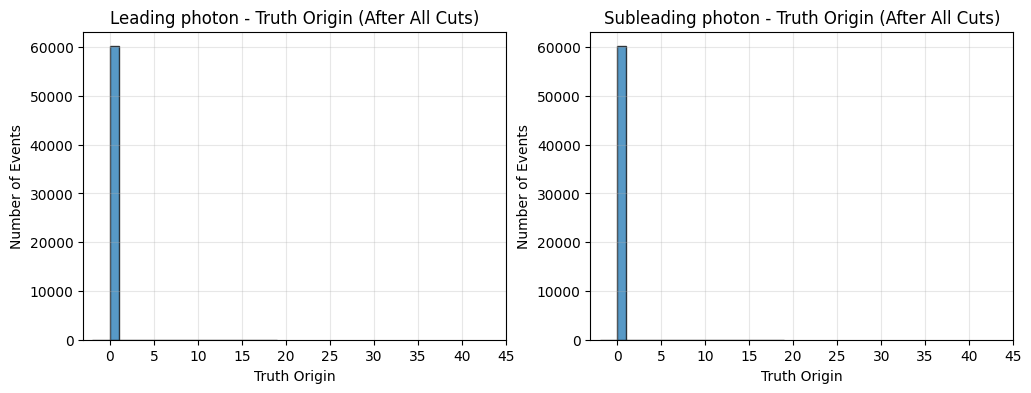

In [21]:
# Leading photon TruthOrigin distribution

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
truthOrigin_lead_np = ak.to_numpy(truthOrigin_lead)
plt.hist(truthOrigin_lead_np, bins= range(-2, 20, 1), edgecolor='black', alpha=0.75)
plt.title('Leading photon - Truth Origin (After All Cuts)')
plt.xlabel('Truth Origin')
plt.ylabel('Number of Events')
plt.xticks(range(0, 46, 5))
plt.grid(alpha= 0.3)


#Subleading photon TruthOrigin distribution

plt.subplot(1, 2, 2)
truthOrigin_sublead_np = ak.to_numpy(truthOrigin_sublead)
plt.hist(truthOrigin_sublead_np, bins = range(-2, 20, 1), edgecolor= 'black', alpha = 0.75)
plt.title('Subleading photon - Truth Origin (After All Cuts)')
plt.xlabel('Truth Origin')
plt.ylabel('Number of Events')
plt.xticks(range(0, 46, 5))
plt.grid(alpha= 0.3)
plt.show()


In [22]:
qcd_df = pd.DataFrame({
    'pt_lead': ak.to_numpy(pt_lead),
    'pt_sublead': ak.to_numpy(pt_sublead),
    'eta_lead': ak.to_numpy(eta_lead),
    'eta_sublead': ak.to_numpy(eta_sublead),
    'phi_lead': ak.to_numpy(phi_lead),
    'phi_sublead': ak.to_numpy(phi_sublead),
    'ptcone20_lead': ak.to_numpy(ptcone20_lead),
    'ptcone20_sublead': ak.to_numpy(ptcone20_sublead),
    'topoetcone20_lead': ak.to_numpy(topoetcone20_lead),
    'topoetcone20_sublead': ak.to_numpy(topoetcone20_sublead),
    'topoetcone40_lead': ak.to_numpy(topoetcone40_lead),
    'topoetcone40_sublead': ak.to_numpy(topoetcone40_sublead),
    'f1_lead': ak.to_numpy(f1_lead),
    'f1_sublead': ak.to_numpy(f1_sublead)
})

print("DataFrame created with shape:", qcd_df.shape)

DataFrame created with shape: (60199, 14)


In [23]:
qcd_df.head()

,pt_lead,pt_sublead,eta_lead,eta_sublead,phi_lead,phi_sublead,ptcone20_lead,ptcone20_sublead,topoetcone20_lead,topoetcone20_sublead,topoetcone40_lead,topoetcone40_sublead,f1_lead,f1_sublead
0,66556.000000,53268.394531,0.562307,1.252950,-0.764428,2.382061,0.0,0.000000,-142.608307,-1206.070801,1676.405273,-1281.612061,0.158990,0.297535
1,41037.347656,36019.644531,-0.293888,1.678105,-1.206149,1.922097,0.0,0.000000,-383.132141,-757.442505,631.050781,-2375.704834,0.333882,0.360787
2,45362.351562,41122.132812,0.351630,2.272317,1.372124,-1.562520,0.0,0.000000,-737.281982,-618.146973,939.159424,-1682.176147,0.361459,0.286767
3,45731.316406,45082.046875,-2.020445,-2.190467,2.240227,-0.590010,0.0,0.000000,-60.485291,2483.375000,2232.513916,2483.196777,0.153818,0.280038
4,60233.699219,51176.687500,0.307793,1.699864,2.069744,-1.788623,0.0,1858.676636,-616.523499,1311.812500,891.409668,3641.469238,0.283645,0.403053


In [24]:
# dataframe saved as a parquet file

qcd_df.to_parquet('../data/processed/qcd_processed.parquet')